In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/master_monthly.csv", parse_dates=["Date"]).set_index("Date")
df = df.dropna().copy()
df.head(), df.tail(), df.shape

(            copper        gold        sp500        kospi  us10y        dxy  \
 Date                                                                         
 2006-02-01  2.1855  561.599976  1280.660034  1371.589966  4.547  90.110001   
 2006-03-01  2.4880  581.799988  1294.869995  1359.599976  4.853  89.730003   
 2006-04-01  3.3355  651.799988  1310.609985  1419.729980  5.069  86.110001   
 2006-05-01  3.7165  642.500000  1270.089966  1317.699951  5.113  84.720001   
 2006-06-01  3.4625  613.500000  1270.199951  1295.150024  5.138  85.220001   
 
                   wti  
 Date                   
 2006-02-01  61.410000  
 2006-03-01  66.629997  
 2006-04-01  71.879997  
 2006-05-01  71.290001  
 2006-06-01  73.980003  ,
             copper         gold        sp500        kospi  us10y         dxy  \
 Date                                                                           
 2024-02-01  3.8345  2045.699951  5096.270020  2642.360107  4.252  104.160004   
 2024-03-01  4.0035  2217.

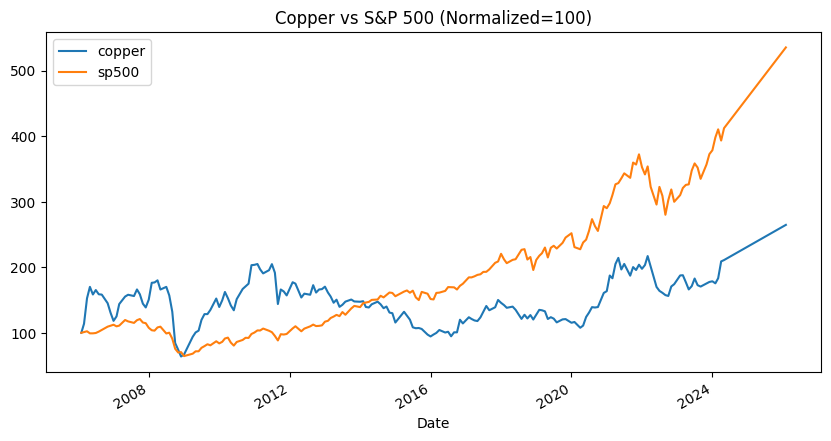

In [2]:
norm = df[["copper","sp500"]] / df[["copper","sp500"]].iloc[0] * 100
norm.plot(figsize=(10,5), title="Copper vs S&P 500 (Normalized=100)")
plt.show()

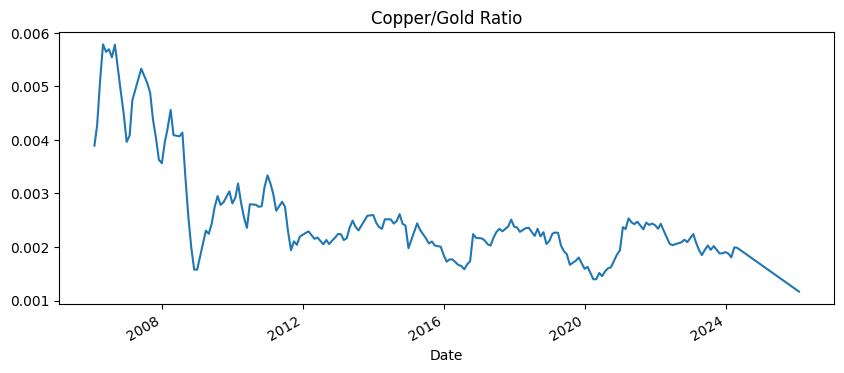

In [3]:
df["copper_gold_ratio"] = df["copper"] / df["gold"]
df["copper_gold_ratio"].plot(figsize=(10,4), title="Copper/Gold Ratio")
plt.show()

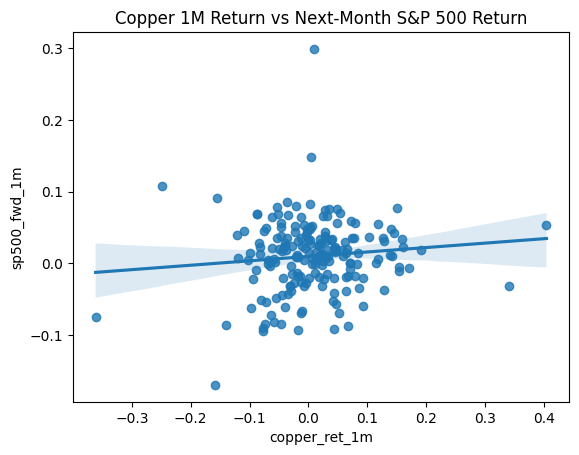

Correlation: 0.10329808620025177


In [4]:
df["copper_ret_1m"] = df["copper"].pct_change()
df["sp500_fwd_1m"] = df["sp500"].pct_change().shift(-1)

tmp = df[["copper_ret_1m","sp500_fwd_1m"]].dropna()
sns.regplot(data=tmp, x="copper_ret_1m", y="sp500_fwd_1m")
plt.title("Copper 1M Return vs Next-Month S&P 500 Return")
plt.show()

print("Correlation:", tmp["copper_ret_1m"].corr(tmp["sp500_fwd_1m"]))

In [5]:
lags = [1,2,3,6,9,12]

# copper lag signal
lag_rows = []
for L in lags:
    lag_rows.append({
    "feature": f"copper_ret_1m_lag{L}",
    "corr_with_sp500_fwd_1m": df["copper_ret_1m"].shift(L).corr(df["sp500_fwd_1m"])
    })

# copper/gold lag signal
df["cg_ratio"] = df["copper"] / df["gold"]
df["cg_ret_1m"] = df["cg_ratio"].pct_change()

for L in lags:
    lag_rows.append({
    "feature": f"cg_ret_1m_lag{L}",
    "corr_with_sp500_fwd_1m": df["cg_ret_1m"].shift(L).corr(df["sp500_fwd_1m"])
    })

lag_df = pd.DataFrame(lag_rows).sort_values("corr_with_sp500_fwd_1m", ascending=False)
lag_df

,feature,corr_with_sp500_fwd_1m
0,copper_ret_1m_lag1,0.126365
10,cg_ret_1m_lag9,0.123621
4,copper_ret_1m_lag9,0.112365
6,cg_ret_1m_lag1,0.096570
1,copper_ret_1m_lag2,0.093341
2,copper_ret_1m_lag3,0.065608
8,cg_ret_1m_lag3,0.063581
7,cg_ret_1m_lag2,0.012730
3,copper_ret_1m_lag6,-0.008467
9,cg_ret_1m_lag6,-0.012396


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

m = df.copy()

# features
m["cg_ratio"] = m["copper"] / m["gold"]
m["copper_ret_1m"] = m["copper"].pct_change()
m["cg_ret_1m"] = m["cg_ratio"].pct_change()

m["x1"] = m["copper_ret_1m"].shift(1)
m["x2"] = m["cg_ret_1m"].shift(9)
m["x3"] = m["copper_ret_1m"].shift(9)
m["x4"] = m["cg_ret_1m"].shift(1)

# target: next-month S&P direction (1=up, 0=down)
m["y"] = (m["sp500"].pct_change().shift(-1) > 0).astype(int)

model_df = m[["x1", "x2", "x3", "x4", "y"]].dropna()

# time split (not random)
split = int(len(model_df) * 0.7)
train = model_df.iloc[:split]
test = model_df.iloc[split:]

X_train = train[["x1", "x2", "x3", "x4"]]
y_train = train["y"]
X_test = test[["x1", "x2", "x3", "x4"]]
y_test = test["y"]

# class_weight helps avoid one-class prediction collapse
clf = LogisticRegression(max_iter=2000, class_weight="balanced")
clf.fit(X_train, y_train)

pred = clf.predict(X_test)

acc = accuracy_score(y_test, pred)
baseline = max(y_test.mean(), 1 - y_test.mean()) # majority-class baseline

print("Test accuracy:", round(acc, 4))
print("Baseline accuracy:", round(baseline, 4))
print("\nPredicted class counts:")
print(pd.Series(pred).value_counts())
print("\nActual class counts:")
print(y_test.value_counts())
print("\nClassification report:")
print(classification_report(y_test, pred, digits=4, zero_division=0))

Test accuracy: 0.5818
Baseline accuracy: 0.6364

Predicted class counts:
1    32
0    23
Name: count, dtype: int64

Actual class counts:
y
1    35
0    20
Name: count, dtype: int64

Classification report:
              precision    recall  f1-score   support

           0     0.4348    0.5000    0.4651        20
           1     0.6875    0.6286    0.6567        35

    accuracy                         0.5818        55
   macro avg     0.5611    0.5643    0.5609        55
weighted avg     0.5956    0.5818    0.5870        55



In [7]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

m = df.copy()
m["cg_ratio"] = m["copper"] / m["gold"]
m["copper_ret_1m"] = m["copper"].pct_change()
m["cg_ret_1m"] = m["cg_ratio"].pct_change()
m["sp500_ret_1m"] = m["sp500"].pct_change()

m["x1"] = m["copper_ret_1m"].shift(1)
m["x2"] = m["cg_ret_1m"].shift(9)
m["x3"] = m["copper_ret_1m"].shift(9)
m["x4"] = m["cg_ret_1m"].shift(1)
m["y"] = (m["sp500_ret_1m"].shift(-1) > 0).astype(int)

m["vol_6m"] = m["sp500_ret_1m"].rolling(6).std()
vol_median = m["vol_6m"].median()
m["regime"] = np.where(m["vol_6m"] >= vol_median, "high_vol", "low_vol")

model_df = m[["x1","x2","x3","x4","y","regime"]].dropna().copy()

In [8]:
dset = model_df.copy()
split = int(len(dset) * 0.7)
train, test = dset.iloc[:split], dset.iloc[split:]
X_train, y_train = train[["x1","x2","x3","x4"]], train["y"]
X_test, y_test = test[["x1","x2","x3","x4"]], test["y"]

clf = LogisticRegression(max_iter=2000, class_weight="balanced")
clf.fit(X_train, y_train)
pred = clf.predict(X_test)

overall_model_acc = accuracy_score(y_test, pred)
overall_baseline = max(y_test.mean(), 1 - y_test.mean())
print("overall", round(overall_model_acc,4), round(overall_baseline,4), round(overall_model_acc-overall_baseline,4))

overall 0.5818 0.6364 -0.0545


In [9]:
dset = model_df[model_df["regime"]=="low_vol"].copy()
split = int(len(dset) * 0.7)
train, test = dset.iloc[:split], dset.iloc[split:]
X_train, y_train = train[["x1","x2","x3","x4"]], train["y"]
X_test, y_test = test[["x1","x2","x3","x4"]], test["y"]

clf = LogisticRegression(max_iter=2000, class_weight="balanced")
clf.fit(X_train, y_train)
pred = clf.predict(X_test)

low_model_acc = accuracy_score(y_test, pred)
low_baseline = max(y_test.mean(), 1 - y_test.mean())
print("low_vol", round(low_model_acc,4), round(low_baseline,4), round(low_model_acc-low_baseline,4))

low_vol 0.5556 0.6667 -0.1111


In [10]:
dset = model_df[model_df["regime"]=="high_vol"].copy()
split = int(len(dset) * 0.7)
train, test = dset.iloc[:split], dset.iloc[split:]
X_train, y_train = train[["x1","x2","x3","x4"]], train["y"]
X_test, y_test = test[["x1","x2","x3","x4"]], test["y"]

clf = LogisticRegression(max_iter=2000, class_weight="balanced")
clf.fit(X_train, y_train)
pred = clf.predict(X_test)

high_model_acc = accuracy_score(y_test, pred)
high_baseline = max(y_test.mean(), 1 - y_test.mean())
print("high_vol", round(high_model_acc,4), round(high_baseline,4), round(high_model_acc-high_baseline,4))

high_vol 0.6429 0.6786 -0.0357


In [11]:
m = df.copy()

m["cg_ratio"] = m["copper"] / m["gold"]

m["copper_ret_1m"] = m["copper"].pct_change()
m["cg_ratio_ret_1m"] = m["cg_ratio"].pct_change()
m["dxy_ret_1m"] = m["dxy"].pct_change()
m["us10y_ret_1m"] = m["us10y"].pct_change()
m["wti_ret_1m"] = m["wti"].pct_change()
m["sp500_ret_1m"] = m["sp500"].pct_change()

m["x1"] = m["copper_ret_1m"].shift(1)
m["x2"] = m["cg_ratio_ret_1m"].shift(1)
m["x3"] = m["copper_ret_1m"].shift(3)
m["x4"] = m["cg_ratio_ret_1m"].shift(3)
m["x5"] = m["dxy_ret_1m"].shift(1)
m["x6"] = m["us10y_ret_1m"].shift(1)
m["x7"] = m["wti_ret_1m"].shift(1)
m["x8"] = m["dxy_ret_1m"].shift(3)
m["x9"] = m["us10y_ret_1m"].shift(3)
m["x10"] = m["wti_ret_1m"].shift(3)

m["y"] = (m["sp500_ret_1m"].shift(-1) > 0).astype(int)

m["vol_6m"] = m["sp500_ret_1m"].rolling(6).std()
vol_median = m["vol_6m"].median()
m["regime"] = np.where(m["vol_6m"] >= vol_median, "high_vol", "low_vol")

feature_cols = ["x1","x2","x3","x4","x5","x6","x7","x8","x9","x10"]
model_df = m[feature_cols + ["y","regime"]].dropna().copy()

# OVERALL
dset = model_df.copy()
split = int(len(dset) * 0.7)
train = dset.iloc[:split]
test = dset.iloc[split:]
X_train = train[feature_cols]
y_train = train["y"]
X_test = test[feature_cols]
y_test = test["y"]
clf = LogisticRegression(max_iter=3000, class_weight="balanced")
clf.fit(X_train, y_train)
pred = clf.predict(X_test)
overall_model = accuracy_score(y_test, pred)
overall_base = max(y_test.mean(), 1 - y_test.mean())

# LOW VOL
dset = model_df[model_df["regime"] == "low_vol"].copy()
split = int(len(dset) * 0.7)
train = dset.iloc[:split]
test = dset.iloc[split:]
X_train = train[feature_cols]
y_train = train["y"]
X_test = test[feature_cols]
y_test = test["y"]
clf = LogisticRegression(max_iter=3000, class_weight="balanced")
clf.fit(X_train, y_train)
pred = clf.predict(X_test)
low_model = accuracy_score(y_test, pred)
low_base = max(y_test.mean(), 1 - y_test.mean())

# HIGH VOL
dset = model_df[model_df["regime"] == "high_vol"].copy()
split = int(len(dset) * 0.7)
train = dset.iloc[:split]
test = dset.iloc[split:]
X_train = train[feature_cols]
y_train = train["y"]
X_test = test[feature_cols]
y_test = test["y"]
clf = LogisticRegression(max_iter=3000, class_weight="balanced")
clf.fit(X_train, y_train)
pred = clf.predict(X_test)
high_model = accuracy_score(y_test, pred)
high_base = max(y_test.mean(), 1 - y_test.mean())

print("overall", round(overall_model,4), round(overall_base,4), round(overall_model-overall_base,4))
print("low_vol", round(low_model,4), round(low_base,4), round(low_model-low_base,4))
print("high_vol", round(high_model,4), round(high_base,4), round(high_model-high_base,4))

overall 0.5714 0.6429 -0.0714
low_vol 0.6552 0.6552 0.0
high_vol 0.5357 0.6786 -0.1429


Regime counts:
regime_3
Risk-ON     62
Neutral     62
Risk-OFF    62
Name: count, dtype: int64

Avg next-month S&P return by regime:
regime_3
Neutral     0.010361
Risk-OFF    0.003730
Risk-ON     0.017207
Name: sp500_next_1m, dtype: float64


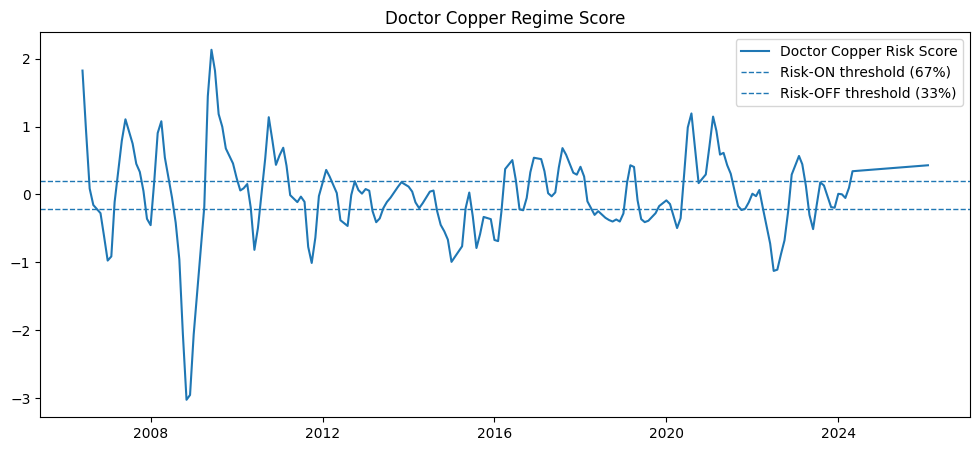

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

m = df.copy()

# --- Core features ---
m["cg_ratio"] = m["copper"] / m["gold"]

m["copper_ret_1m"] = m["copper"].pct_change()
m["cg_ret_1m"] = m["cg_ratio"].pct_change()
m["dxy_ret_1m"] = m["dxy"].pct_change()
m["us10y_ret_1m"] = m["us10y"].pct_change()
m["wti_ret_1m"] = m["wti"].pct_change()
m["sp500_ret_1m"] = m["sp500"].pct_change()

# --- Smooth signals (3m average) ---
m["sig_copper"] = m["copper_ret_1m"].rolling(3).mean()
m["sig_cg"] = m["cg_ret_1m"].rolling(3).mean()
m["sig_dxy"] = m["dxy_ret_1m"].rolling(3).mean()
m["sig_us10y"] = m["us10y_ret_1m"].rolling(3).mean()
m["sig_wti"] = m["wti_ret_1m"].rolling(3).mean()

# --- Standardize to z-scores ---
for c in ["sig_copper","sig_cg","sig_dxy","sig_us10y","sig_wti"]:
    mu = m[c].mean()
    sd = m[c].std()
    m[c + "_z"] = (m[c] - mu) / sd

# --- Regime score construction ---
# Positive risk signals: copper, copper/gold, wti
# Negative risk signals: dxy, us10y (higher = tighter conditions)
m["risk_score_raw"] = (
0.35 * m["sig_copper_z"] +
0.25 * m["sig_cg_z"] +
0.15 * m["sig_wti_z"] -
0.15 * m["sig_dxy_z"] -
0.10 * m["sig_us10y_z"]
)

# Smooth final score
m["risk_score"] = m["risk_score_raw"].rolling(2).mean()

# --- 3-state regime labels ---
# Use percentile thresholds from historical distribution
low_th = m["risk_score"].quantile(0.33)
high_th = m["risk_score"].quantile(0.67)

m["regime_3"] = np.where(
m["risk_score"] >= high_th, "Risk-ON",
np.where(m["risk_score"] <= low_th, "Risk-OFF", "Neutral")
)

# --- Quick diagnostics ---
out = m[["risk_score","regime_3","sp500_ret_1m"]].dropna().copy()
print("Regime counts:")
print(out["regime_3"].value_counts())

print("\nAvg next-month S&P return by regime:")
# next-month return aligned to current regime
out["sp500_next_1m"] = out["sp500_ret_1m"].shift(-1)
print(out.groupby("regime_3")["sp500_next_1m"].mean())

# --- Plot score + thresholds ---
plt.figure(figsize=(12,5))
plt.plot(m.index, m["risk_score"], label="Doctor Copper Risk Score")
plt.axhline(high_th, linestyle="--", linewidth=1, label="Risk-ON threshold (67%)")
plt.axhline(low_th, linestyle="--", linewidth=1, label="Risk-OFF threshold (33%)")
plt.title("Doctor Copper Regime Score")
plt.legend()
plt.show()

In [13]:
import numpy as np
import pandas as pd
from scipy import stats

r = m[["risk_score","regime_3","sp500_ret_1m"]].dropna().copy()
r["sp500_next_1m"] = r["sp500_ret_1m"].shift(-1)
r = r.dropna()

# 1) Basic summary
summary = r.groupby("regime_3")["sp500_next_1m"].agg(["count","mean","median","std"])
summary["mean_pct"] = summary["mean"] * 100
summary["median_pct"] = summary["median"] * 100
summary["std_pct"] = summary["std"] * 100
print("=== Forward Return Summary by Regime ===")
display(summary)

# 2) Positive-return hit rate by regime
hit = r.groupby("regime_3").apply(lambda x: (x["sp500_next_1m"] > 0).mean()).to_frame("hit_rate")
hit["hit_rate_pct"] = hit["hit_rate"] * 100
print("\n=== Hit Rate (next-month S&P > 0) ===")
display(hit)

# 3) Risk-ON vs Risk-OFF difference test
on = r.loc[r["regime_3"]=="Risk-ON","sp500_next_1m"]
off = r.loc[r["regime_3"]=="Risk-OFF","sp500_next_1m"]

mean_diff = on.mean() - off.mean()
t_stat, p_val = stats.ttest_ind(on, off, equal_var=False, nan_policy="omit")

print("\n=== Risk-ON vs Risk-OFF Test ===")
print(f"Mean diff (ON - OFF): {mean_diff:.4f} ({mean_diff*100:.2f}%)")
print(f"T-stat: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")

# 4) Simple interpretation text helper
if p_val < 0.05:
    sig = "statistically significant at 5%"
elif p_val < 0.10:
    sig = "marginally significant at 10%"
else:
    sig = "not statistically significant"

print(f"Interpretation: ON vs OFF spread is {sig}.")

=== Forward Return Summary by Regime ===


,count,mean,median,std,mean_pct,median_pct,std_pct
regime_3,,,,,,,
Neutral,62,0.010361,0.015327,0.047159,1.036135,1.532747,4.715896
Risk-OFF,62,0.003730,0.010236,0.053004,0.373034,1.023568,5.300433
Risk-ON,61,0.017207,0.018201,0.051049,1.720743,1.820076,5.104891



=== Hit Rate (next-month S&P > 0) ===


,hit_rate,hit_rate_pct
regime_3,,
Neutral,0.661290,66.129032
Risk-OFF,0.596774,59.677419
Risk-ON,0.688525,68.852459



=== Risk-ON vs Risk-OFF Test ===
Mean diff (ON - OFF): 0.0135 (1.35%)
T-stat: 1.4364
P-value: 0.1535
Interpretation: ON vs OFF spread is not statistically significant.
